In [12]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import sunpy.visualization.colormaps as sunpycm
import torch
from omegaconf import OmegaConf
from loguru import logger as lgr_logger

from sdofmv2.core import MAE, MAE_old, SDOMLDataModule
from sdofmv2.utils import ALL_WAVELENGTHS

In [3]:
cfg = OmegaConf.load(
    "../../configs/pretrain/pretrain_mae_AIA.yaml"
    )

cfg_old = OmegaConf.load(
    "../../configs/pretrain/pretrain_mae_AIA_old.yaml"
)

In [5]:
data_module = SDOMLDataModule(
    hmi_path=os.path.join(
        cfg.data.sdoml.base_directory, 
        cfg.data.sdoml.sub_directory.hmi
    ) if cfg.data.sdoml.sub_directory.hmi else None,
    aia_path=os.path.join(
        cfg.data.sdoml.base_directory,
        cfg.data.sdoml.sub_directory.aia,
    ) if cfg.data.sdoml.sub_directory.aia else None,
    eve_path=None,
    components=cfg.data.sdoml.components,
    wavelengths=cfg.data.sdoml.wavelengths,
    ions=cfg.data.sdoml.ions,
    frequency=cfg.data.sdoml.frequency,
    batch_size=cfg.model.misc.batch_size,
    num_workers=cfg.data.num_workers,
    val_months=cfg.data.month_splits.val,
    test_months=cfg.data.month_splits.test,
    holdout_months=cfg.data.month_splits.holdout,
    cache_dir=os.path.join(
        "../../assets",
        cfg.data.sdoml.sub_directory.cache,
    ),
    min_date=cfg.data.min_date,
    max_date=cfg.data.max_date,
    num_frames=cfg.model.mae.num_frames,
    drop_frame_dim=cfg.data.drop_frame_dim,
    apply_mask=cfg.data.sdoml.apply_mask,
    precision=cfg.experiment.precision,
    normalization=cfg.data.sdoml.normalization,
)
data_module.setup()


data_module_for_old = SDOMLDataModule(
    hmi_path=os.path.join(
        cfg_old.data.sdoml.base_directory, 
        cfg_old.data.sdoml.sub_directory.hmi
    ) if cfg_old.data.sdoml.sub_directory.hmi else None,
    aia_path=os.path.join(
        cfg_old.data.sdoml.base_directory,
        cfg_old.data.sdoml.sub_directory.aia,
    ) if cfg_old.data.sdoml.sub_directory.aia else None,
    eve_path=None,
    components=cfg_old.data.sdoml.components,
    wavelengths=cfg_old.data.sdoml.wavelengths,
    ions=cfg_old.data.sdoml.ions,
    frequency=cfg_old.data.sdoml.frequency,
    batch_size=cfg_old.model.misc.batch_size,
    num_workers=cfg_old.data.num_workers,
    val_months=cfg_old.data.month_splits.val,
    test_months=cfg_old.data.month_splits.test,
    holdout_months=cfg_old.data.month_splits.holdout,
    cache_dir=os.path.join(
        "../../assets",
        cfg_old.data.sdoml.sub_directory.cache,
    ),
    min_date=cfg_old.data.min_date,
    max_date=cfg_old.data.max_date,
    num_frames=cfg_old.model.mae.num_frames,
    drop_frame_dim=cfg_old.data.drop_frame_dim,
    apply_mask=cfg_old.data.sdoml.apply_mask,
    precision=cfg_old.experiment.precision,
    normalization=cfg_old.data.sdoml.normalization,
)
data_module_for_old.setup()

[* CACHE SYSTEM *] Found cached index data in ../../assets/cache/aligndata_AIA_FULL_12min_2010-05-0100:00:00-2018-12-3123:59:59.csv.


2026-03-09 02:13:27.716 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../assets/cache/AIA/131A_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-03-09 02:13:27.717 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../assets/cache/AIA/1600A_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-03-09 02:13:27.718 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../assets/cache/AIA/1700A_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-03-09 02:13:27.719 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../assets/cache/AIA/171A_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-03-09 02:13:27.719 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../assets/cache/AIA/193A_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-03-09 02:13:27.719 | INFO     | sdofmv2.core.datamodu

[* CACHE SYSTEM *] Found cached HMI mask data in ../../assets/cache/hmi_mask_512x512.npy.
[* CACHE SYSTEM *] Found cached index data in ../../assets/cache/aligndata_AIA_FULL_12min_2010-05-0100:00:00-2018-12-3123:59:59.csv.


2026-03-09 02:13:28.055 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../assets/cache/AIA/131A_2010-05-0100:00:00-2018-12-3123:59:59_norm-zscore.json
2026-03-09 02:13:28.058 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../assets/cache/AIA/1600A_2010-05-0100:00:00-2018-12-3123:59:59_norm-zscore.json
2026-03-09 02:13:28.059 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../assets/cache/AIA/1700A_2010-05-0100:00:00-2018-12-3123:59:59_norm-zscore.json
2026-03-09 02:13:28.060 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../assets/cache/AIA/171A_2010-05-0100:00:00-2018-12-3123:59:59_norm-zscore.json
2026-03-09 02:13:28.060 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../assets/cache/AIA/193A_2010-05-0100:00:00-2018-12-3123:59:59_norm-zscore.json
2026-03-09 02:13:28.061 | INFO     | sdofmv

[* CACHE SYSTEM *] Found cached HMI mask data in ../../assets/cache/hmi_mask_512x512.npy.


In [6]:
wavelenghs = ALL_WAVELENGTHS
wavelenghs.sort()

wave_val_list = []
for wave in wavelenghs:
    val = wave[:-1]
    wave_val_list.append(int(val))

wave_arr = np.array(wave_val_list)
sort_ids = np.argsort(wave_arr)

cms = [
    sunpycm.cmlist.get("sdoaia131"),
    sunpycm.cmlist.get("sdoaia1600"),
    sunpycm.cmlist.get("sdoaia1700"),
    sunpycm.cmlist.get("sdoaia171"),
    sunpycm.cmlist.get("sdoaia193"),
    sunpycm.cmlist.get("sdoaia211"),
    sunpycm.cmlist.get("sdoaia304"),
    sunpycm.cmlist.get("sdoaia335"),
    sunpycm.cmlist.get("sdoaia94"),
]

In [7]:
ckpt_dir = "../../assets/check_point/backbone/"
model = MAE.load_from_checkpoint(
    checkpoint_path= ckpt_dir + "AIA/id_6lfzuk01_mae_epoch=76-val_loss=0.00.ckpt", 
    map_location="cpu",
    weights_only=False)
lgr_logger.info(f"masking ratio of sdofmv2: {model.masking_ratio}")

2026-03-09 02:13:40.625 | INFO     | __main__:<module>:6 - masking ratio of sdofmv2: 0.5


In [8]:
timestamps = [
    "2011-12-25 00:12:00",
    # "2012-12-25 00:12:00",
    # "2013-12-25 00:12:00",
    ]

img_indices = [
    data_module.test_ds.aligndata.index.get_loc(
        pd.to_datetime(i_time)
    ) for i_time in timestamps
]

x_set = torch.cat([data_module.test_ds[i][0].unsqueeze(0) for i in img_indices], dim=0)
ts = [pd.to_datetime(data_module.test_ds[i][1]) for i in img_indices]
print(f"Datetime: {ts}")

Datetime: [Timestamp('2011-12-25 00:12:00')]


In [9]:
model.eval()

with torch.no_grad():
    output_25 = model(x_set, mask_ratio=0.25)
    output_50 = model(x_set, mask_ratio=0.50)
    output_85 = model(x_set, mask_ratio=0.85)
    output_95 = model(x_set, mask_ratio=0.95)

In [10]:
def visualize_masked_regions(model_output):

    patch_size = 16
    # visualize masking
    mask_grid = model_output[1][0].reshape(512 // patch_size, 512 // patch_size)
    mask_full = np.kron(mask_grid, np.ones((patch_size, patch_size)))
    mask_full = torch.tensor(mask_full, dtype=bool)
    
    results = []
    for ch_id in range(9):
        img_slice = model_output[0][0, ch_id, 0, :, :].cpu().numpy()
        isolated_regions = np.where(~mask_full.cpu().numpy(), img_slice, np.nan)
        results.append(isolated_regions)

    return np.stack(results, axis=0)

def clean_limb(model_output, limb_mask):

    results = []
    for ch_id in range(9):
        img_ch = model_output[0][0, ch_id, 0, :, :].cpu().numpy()
        imgage_without_limb = np.where(
            limb_mask!=0, 
            img_ch, 
            np.nan
        )
        results.append(imgage_without_limb)

    return np.stack(results, axis=0)

In [11]:
masked_output = []
output_wo_limb = []
output_list = [
    output_25,
    output_50,
    output_85,
    output_95
]

for i, output in enumerate(output_list):
    masked_output.append(visualize_masked_regions(output))
    output_wo_limb.append(clean_limb(output, model.limb_mask))


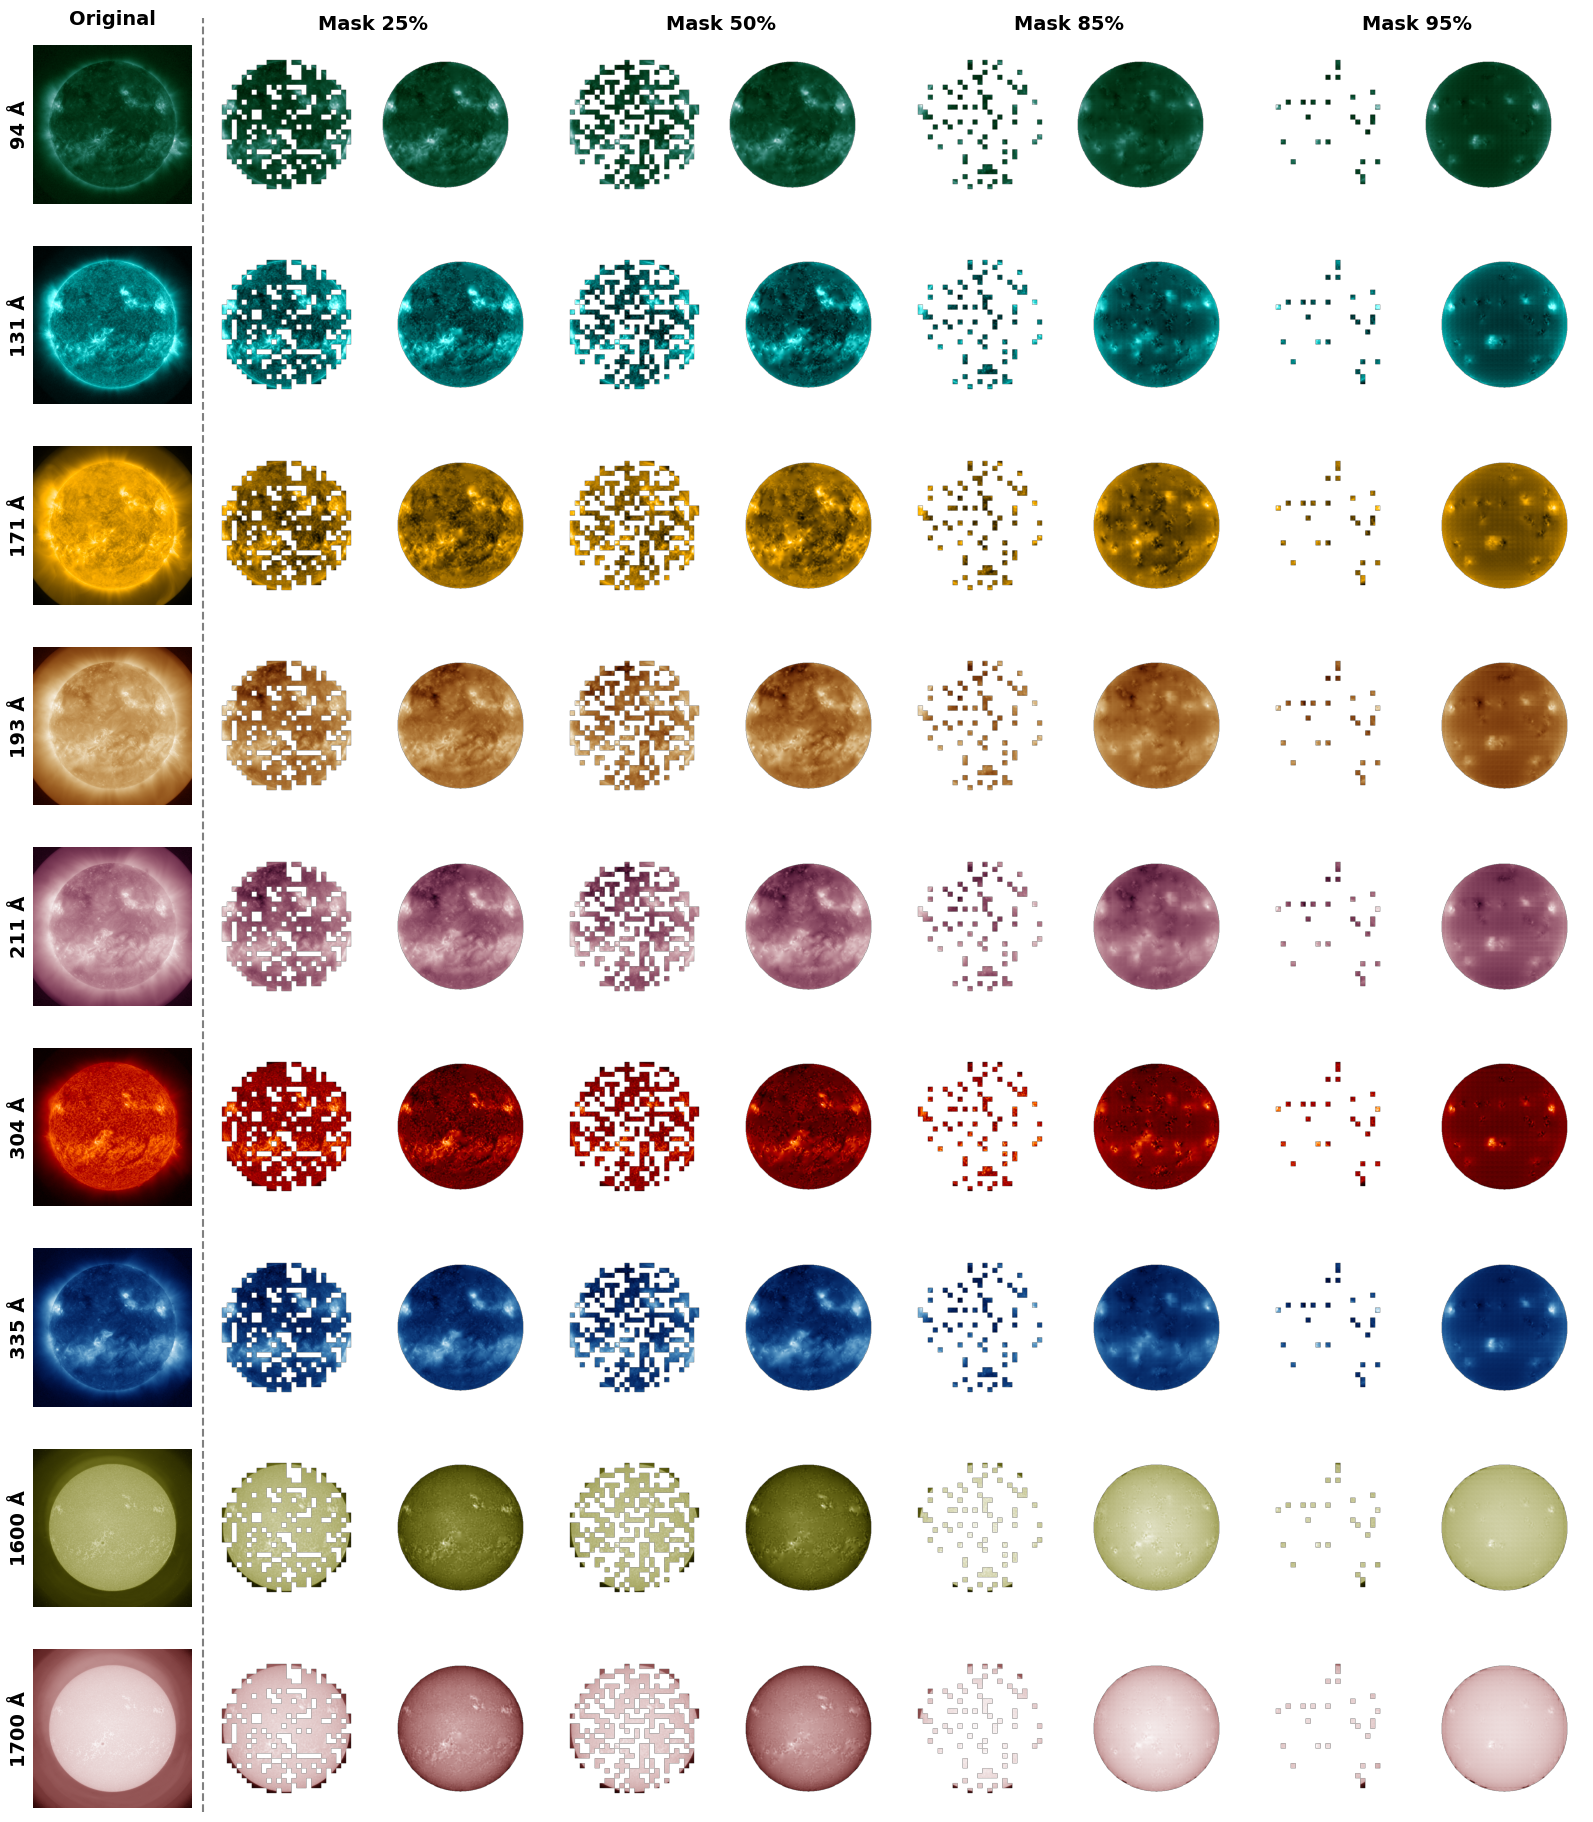

In [13]:
fig = plt.figure(figsize=(20, 23))
gs = gridspec.GridSpec(9, 9, figure=fig, wspace=0.1) # Default gap

def clean_ax(ax):
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

for i_ch, ch_index in enumerate(sort_ids):
    ax_ch = fig.add_subplot(gs[i_ch, 0])
    if i_ch == 0:
        ax_ch.set_title("Original", fontsize=14, weight='bold', pad=15)
    ax_ch.imshow(x_set[0, ch_index, 0, :, :], cmap=cms[ch_index])
    clean_ax(ax_ch)

    try:
        ax_ch.set_ylabel(f"{wave_arr[ch_index]} Å", fontsize=14, weight='bold',
                         rotation='vertical', ha='center', va='center', labelpad=10)
    except IndexError:
        print(f"Warning: Missing label for channel index {i_ch}")

line_x = 0.21
fig.add_artist(plt.Line2D((line_x, line_x), (0.11, 0.89), color='gray', lw=1.5, ls='--'))

pairs = []
masking_ratio = ["25%", "50%", "85%", "95%"]
for masked_imgs, output_wo_limb_imgs, ratio in zip(masked_output, output_wo_limb, masking_ratio):
    pairs.append(
        (masked_imgs, output_wo_limb_imgs, ratio)
    )
    

for i, (masked, full, percent) in enumerate(pairs):
    
    for i_ch, ch_index in enumerate(sort_ids):
        # Left of pair (Masked)
        idx_m = 1 + (i * 2)
        ax_m = fig.add_subplot(gs[i_ch, idx_m])
        ax_m.imshow(masked[ch_index, :, :], cmap=cms[ch_index])
        clean_ax(ax_m)
    
        # Right of pair (Reconstructed)
        idx_f = 2 + (i * 2)
        ax_f = fig.add_subplot(gs[i_ch, idx_f])
        ax_f.imshow(full[ch_index, :, :], cmap=cms[ch_index])
        clean_ax(ax_f)

        if i_ch == 0:
            # Tighten the pair by moving the right image closer to the left
            # This overrides the global wspace for these specific axes
            pos_m = ax_m.get_position()
            pos_f = ax_f.get_position()
            ax_f.set_position([pos_m.x1, pos_f.y0, pos_f.width, pos_f.height])
        
            # Center title over the pair
            center_x = (pos_m.x0 + pos_f.x1) / 2
            fig.text(center_x, 0.885, f"Mask {percent}", ha='center', fontsize=14, weight="bold")

plt.savefig(f"SDOFMv2_results_per_masking.pdf", dpi=300, bbox_inches="tight")
plt.show()